In [1]:
import sys
sys.executable
import requests
import pandas as pd
import os
import matplotlib.pyplot as plt


#Here we called the Codeforces api
def fetch(handle,limit=10000):
    url=f"https://codeforces.com/api/user.status?handle={handle}&count={limit}"
    response=requests.get(url,timeout=20)

    if response.status_code!=200:
        raise Exception("Nothing Found")
    data=response.json()
    if data["status"]!="OK":
        raise Exception(data["status"])
    return data["result"]

#Here we converted json file to csv file
def csv_con(handle,submissions):
    rows=[]
    for sub in submissions:
        row={
            "Handle":handle,
            "Contest_ID":sub["problem"]["contestId"],
            "Problem_Index":sub["problem"]["index"],
            "Problem_Name":sub["problem"]["name"],
            "verdict":sub.get("verdict"),
            "language": sub.get("programmingLanguage"),
            "timestamp": sub.get("creationTimeSeconds")
        }
        rows.append(row)
        
    df=pd.DataFrame(rows)
    os.makedirs("data",exist_ok=True)
    file_path=f"data/{handle}_submissios.csv"
    df.to_csv(file_path,index=False)

    return file_path

def extract_tags(sub):
    return sub.get("problem", {}).get("tags", [])

#Main function starts here
handle=input("Enter Codeforces Handle: ")
submissions=fetch(handle)
csv_file=csv_con(handle,submissions)

/Users/wizard/cf_analyzer/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Enter Codeforces Handle:  cp_wiz


Total submissions:  503
Unique problems tried: 293
Problems Solved: 279
verdict
OK                       306
WRONG_ANSWER             162
COMPILATION_ERROR         20
TIME_LIMIT_EXCEEDED       11
RUNTIME_ERROR              3
MEMORY_LIMIT_EXCEEDED      1
Name: count, dtype: int64


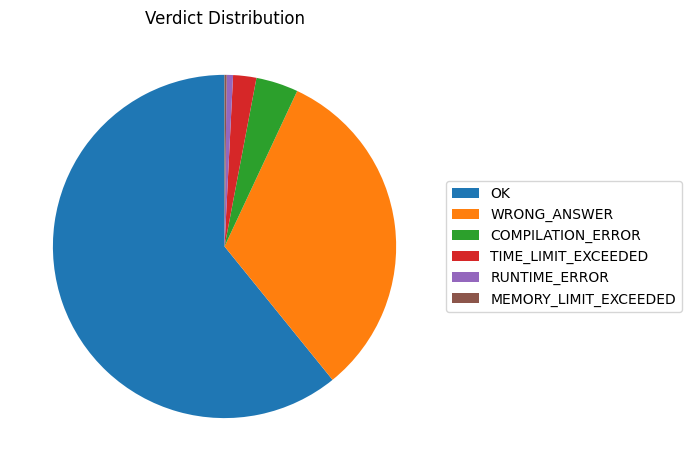

In [2]:

print("Total submissions: ",len(submissions))
df=pd.read_csv(csv_file)
#df.head()
#these 2 line works for testing
print("Unique problems tried:", df[["Contest_ID","Problem_Index"]].drop_duplicates().shape[0])
tried = df[["Contest_ID","Problem_Index"]].drop_duplicates()
solved = df[df["verdict"]=="OK"][["Contest_ID","Problem_Index"]].drop_duplicates()

#print("Problems Tried:", len(tried))
print("Problems Solved:", len(solved))
verdict_count = df["verdict"].value_counts()
print(verdict_count) 
plt.figure(figsize=(7,7))

verdict_count.plot(
    kind="pie",
    labels=None,
    startangle=90
)

plt.title("Verdict Distribution")
plt.ylabel("")

plt.legend(
    verdict_count.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

In [3]:
tags = []
for sub in submissions:
    tags.extend(extract_tags(sub))
tags_df = pd.Series(tags)
tag_count = tags_df.value_counts()
tag_count.head(12)


implementation             209
math                       207
greedy                     156
constructive algorithms     89
brute force                 86
strings                     57
sortings                    50
number theory               45
dp                          18
binary search               14
data structures             13
games                       10
Name: count, dtype: int64

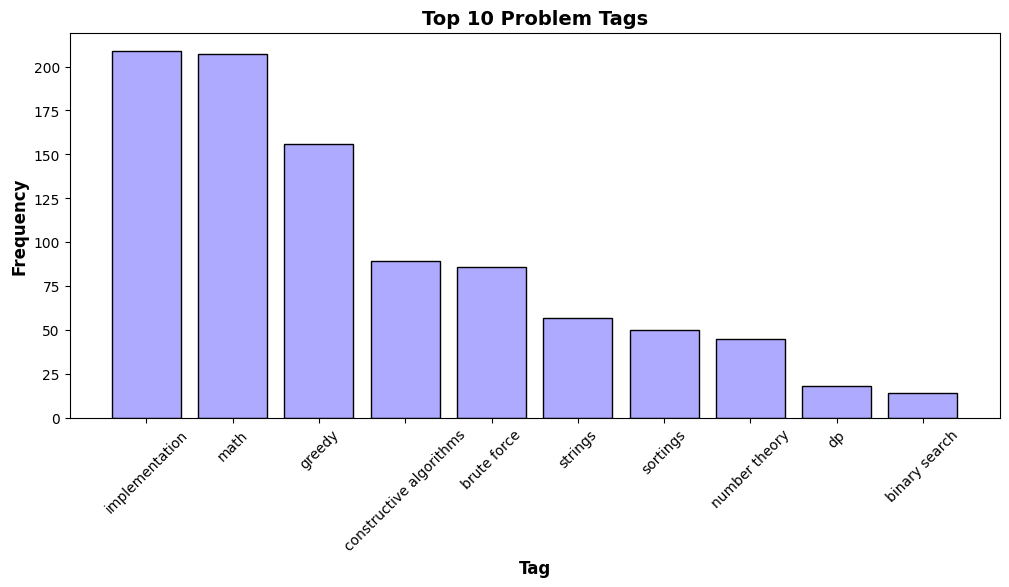

In [4]:

plt.figure(figsize=(12,5))
plt.bar(
    tag_count.head(10).index[::1], 
    tag_count.head(10).values[::1], 
    color="#aeaaff",
    edgecolor='black'
)
plt.xticks(rotation=45)
plt.title("Top 10 Problem Tags", fontsize=14, fontweight='bold')
plt.xlabel("Tag", fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontsize=12, fontweight='bold')
plt.show()

In [5]:
print("Languages used:", df["language"].nunique())
language_count = df["language"].value_counts()
language_count

Languages used: 4


language
C++23 (GCC 14-64, msys2)    345
GNU C11                     101
C++17 (GCC 7-32)             40
C++20 (GCC 13-64)            17
Name: count, dtype: int64

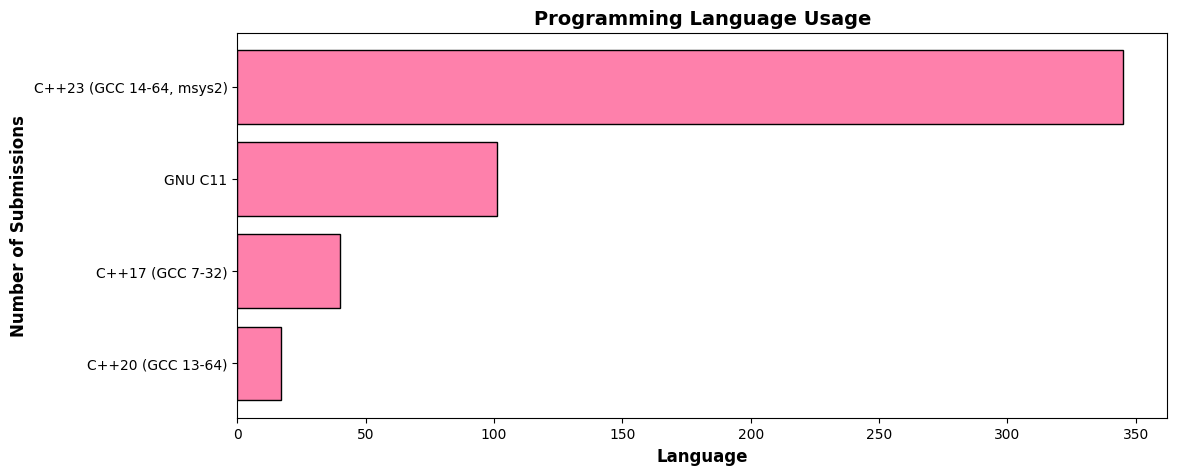

In [6]:
plt.figure(figsize=(12,5))
plt.barh(
    language_count.head(10).index[::-1], 
    language_count.head(10).values[::-1], 
    color='#fe80ab',
    edgecolor='black'
)
plt.title("Programming Language Usage", fontsize=14, fontweight='bold')
plt.xlabel("Language", fontsize=12, fontweight='bold')
plt.ylabel("Number of Submissions", fontsize=12, fontweight='bold')
plt.show()

In [7]:
from collections import defaultdict
wa_count = defaultdict(int)
tle_count = defaultdict(int)
for sub in submissions:
    verdict = sub.get("verdict")
    tags = sub.get("problem", {}).get("tags", [])
    for tag in tags:
        if verdict == "WRONG_ANSWER":
            wa_count[tag] += 1
        elif verdict == "TIME_LIMIT_EXCEEDED":
            tle_count[tag] += 1
print("Top 10 Tags with Highest Wrong Answers:\n")
for tag, count in sorted(wa_count.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{tag:<25}{count}")
print("\nTop 10 Tags with Highest Time Limit Exceeded:\n")
for tag, count in sorted(tle_count.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{tag:<25}{count}")

Top 10 Tags with Highest Wrong Answers:

math                     78
implementation           58
greedy                   53
constructive algorithms  40
brute force              24
number theory            17
strings                  17
sortings                 13
binary search            6
dp                       6

Top 10 Tags with Highest Time Limit Exceeded:

implementation           8
math                     5
greedy                   5
binary search            4
two pointers             4
data structures          4
brute force              4
sortings                 1
dp                       1


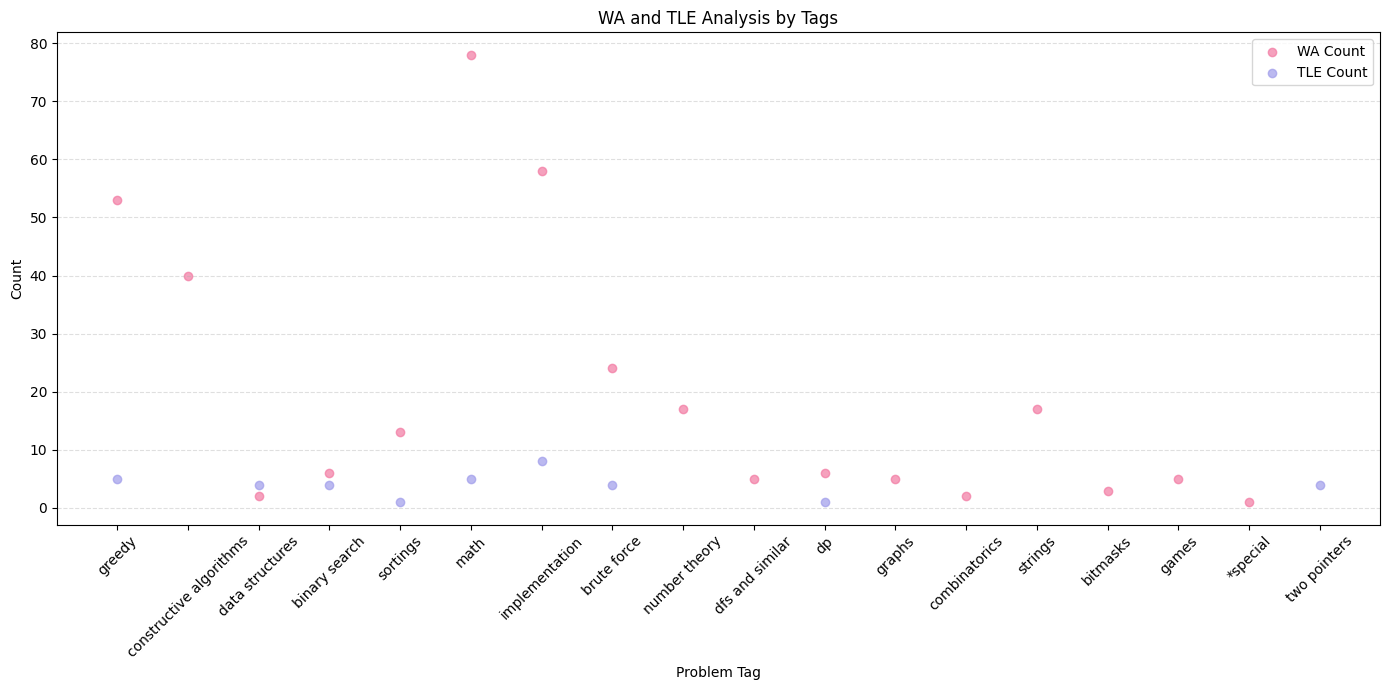

In [8]:
wa_df = pd.DataFrame(wa_count.items(), columns=["Tag", "WA_Count"])
tle_df = pd.DataFrame(tle_count.items(), columns=["Tag", "TLE_Count"])
plt.figure(figsize=(14,7))

# WA scatter
plt.scatter(
    wa_df["Tag"],
    wa_df["WA_Count"],
    color='#f279a2',
    alpha=0.7,
    label='WA Count'
)

# TLE scatter
plt.scatter(
    tle_df["Tag"],
    tle_df["TLE_Count"],
    color='#9f9cea',
    alpha=0.7,
    label='TLE Count'
)

plt.xlabel("Problem Tag")
plt.ylabel("Count")
plt.title("WA and TLE Analysis by Tags")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Weak Tags (Attempted >=5 and AC Ratio < 0.4):

            Tag  Attempts  Solved  AC_Ratio
  binary search        14       4      0.29
         graphs         7       2      0.29
dfs and similar         8       3      0.38


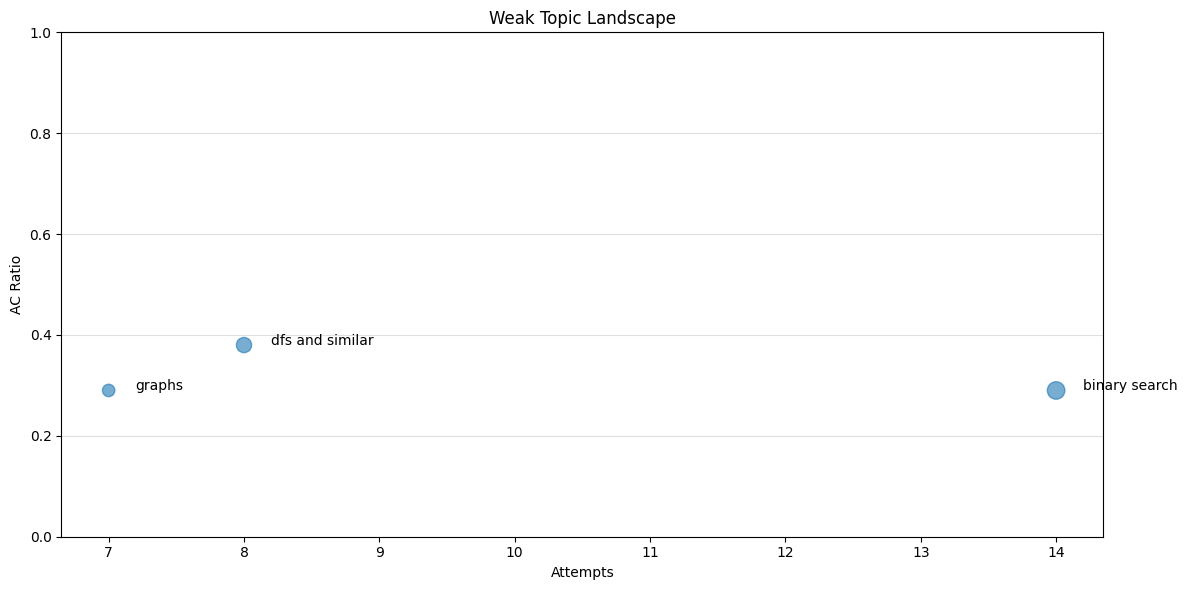

In [9]:
weak = []
for tag in tag_count.index:
    total = 0
    solved = 0
    for sub in submissions:
        problem = sub.get("problem", {})
        tags = problem.get("tags", [])
        if tag in tags:
            total += 1
            if sub.get("verdict") == "OK":
                solved += 1
    if total >= 5:
        ac_ratio = solved / total
        if ac_ratio < 0.5:
            weak.append({
                "Tag": tag,
                "Attempts": total,
                "Solved": solved,
                "AC_Ratio": round(ac_ratio, 2)
            })
weak_sorted = sorted(weak, key=lambda x: x["AC_Ratio"])
print("Weak Tags (Attempted >=5 and AC Ratio < 0.4):\n")
weak_df = pd.DataFrame(weak_sorted)
weak_df = weak_df[["Tag", "Attempts", "Solved", "AC_Ratio"]]
print(weak_df.to_string(index=False))
plt.figure(figsize=(12,6))
plt.scatter(
    weak_df["Attempts"],
    weak_df["AC_Ratio"],
    s=weak_df["Solved"] * 40,
    alpha=0.6
)
for i in range(len(weak_df)):
    plt.text(
        weak_df["Attempts"][i] + 0.2,
        weak_df["AC_Ratio"][i],
        weak_df["Tag"][i]
    )
plt.xlabel("Attempts")
plt.ylabel("AC Ratio")
plt.title("Weak Topic Landscape")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="-", alpha=0.4)
plt.tight_layout()
plt.show()